In [ ]:
#Load the dataset
import pandas as pd
df = pd.read_csv("../data/predictive_maintenance.csv")

Inspect columns, data types, distributions

In [3]:
df.head()
# This shows the first 5 rows of the dataframe.

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [ ]:
df.shape
##number of rows and columns

(10000, 10)

In [5]:
df.columns
#list of column names

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')

In [6]:
df.info()
#summary of the dataframe including data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [7]:
df.isnull().sum()
#checking for missing values in each column

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

Remove ID columns To make sure the model learns from machine behaviour, not identifiers

In [8]:
df = df.drop(columns=["UDI", "Product ID"])
#dropping unnecessary columns


In [ ]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target',
       'Failure Type'],
      dtype='object')

Encode categorical variables Using one hot encoding

In [10]:
df["Type"].value_counts()
#count of each category in the 'Type' column

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [11]:
df = pd.get_dummies(df, columns=["Type"], drop_first=True)
df.columns

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target',
       'Failure Type', 'Type_L', 'Type_M'],
      dtype='object')

In [12]:
df["Failure Type"].value_counts()
#count of each category in the target column 'Failure Type'

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [ ]:
X = df.drop(columns=["Target", "Failure Type"])
y = df["Target"]
#X = input sensor + machine features
#y = output (Failure: Yes / No)
#We exclude Failure Type because:It is NOT known at prediction time
#Using it would cause data leakage

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,#20% data for testing
    random_state=42,#for reproducibility
    stratify=y#keeps failure ratio same in train & test
)

Identify class imbalance

In [15]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))
#Confirms both sets have similar failure percentages
#Proves correct experimental design

Training target distribution:
Target
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Testing target distribution:
Target
0    0.966
1    0.034
Name: proportion, dtype: float64


Trin the Decision tree here It's the first AI model

In [16]:
from sklearn.tree import DecisionTreeClassifier
#importing the Decision Tree Classifier model

In [17]:
dt_model = DecisionTreeClassifier(
    random_state=42, #make results reproducible
    class_weight="balanced", #personalize missed failures
    max_depth=6 #prevent overfitting
)

In [18]:
dt_model.fit(X_train, y_train)
#The tree learns if–else rules
#It finds the best feature splits to separate failures from non-failures

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [19]:
y_pred = dt_model.predict(X_test)
#Predicts failure (0 / 1) for unseen data
#Used to evaluate performance

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print("\n")
print(classification_report(y_test, y_pred))
#Evaluates model performance using confusion matrix and classification report

[[1815  117]
 [  10   58]]


              precision    recall  f1-score   support

           0       0.99      0.94      0.97      1932
           1       0.33      0.85      0.48        68

    accuracy                           0.94      2000
   macro avg       0.66      0.90      0.72      2000
weighted avg       0.97      0.94      0.95      2000



Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier
#importing the Random Forest Classifier model

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=200, #number of trees
    random_state=42, #same results every run
    class_weight="balanced", #forcus on rare failures
    max_depth=None, #let trees grow naturally
    n_jobs=-1 #use all CPU cores
)


In [23]:
rf_model.fit(X_train, y_train)
#Each tree learns from a random subset of data
#Each tree sees different features
#Final model becomes robust and general

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
y_pred_rf = rf_model.predict(X_test)
#Predicts failure (0 / 1) for unseen data using Random Forest model

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_rf))
print("\n")
print(classification_report(y_test, y_pred_rf))
#Evaluates Random Forest model performance using confusion matrix and classification report

[[1929    3]
 [  36   32]]


              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.91      0.47      0.62        68

    accuracy                           0.98      2000
   macro avg       0.95      0.73      0.81      2000
weighted avg       0.98      0.98      0.98      2000



Tune the Random Forest threshold

In [27]:
y_prob_rf = rf_model.predict_proba(X_test)
#Predict Failure if probability ≥ 0.30 (or 0.25)

In [28]:
import numpy as np

threshold = 0.30
y_pred_rf_tuned = (y_prob_rf[:, 1] >= threshold).astype(int)
#Custom thresholding to catch more failures

In [29]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_rf_tuned))
print("\n")
print(classification_report(y_test, y_pred_rf_tuned))
#Evaluates tuned Random Forest model performance with custom threshold

[[1919   13]
 [  19   49]]


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.79      0.72      0.75        68

    accuracy                           0.98      2000
   macro avg       0.89      0.86      0.87      2000
weighted avg       0.98      0.98      0.98      2000



In [30]:
for t in [0.5, 0.4, 0.3, 0.25]:
    y_pred_temp = (y_prob_rf[:, 1] >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred_temp))


Threshold: 0.5
[[1929    3]
 [  36   32]]

Threshold: 0.4
[[1924    8]
 [  25   43]]

Threshold: 0.3
[[1919   13]
 [  19   49]]

Threshold: 0.25
[[1912   20]
 [  17   51]]


In [31]:
FINAL_THRESHOLD = 0.30

Failure Type Prediction

In [32]:
df_failures = df[df["Target"] == 1]
#Failure type exists only when Target = 1
#Including non-failures would confuse the model

In [33]:
X_fail = df_failures.drop(columns=["Target", "Failure Type"])
y_fail = df_failures["Failure Type"]
#Features and target for failure type classification

In [34]:
from sklearn.model_selection import train_test_split

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fail,
    y_fail,
    test_size=0.2,
    random_state=42,
    stratify=y_fail
)


In [35]:
rf_failure_type = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_failure_type.fit(Xf_train, yf_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_ft = rf_failure_type.predict(Xf_test)

print(confusion_matrix(yf_test, y_pred_ft))
print("\n")
print(classification_report(yf_test, y_pred_ft))


[[22  0  0  0  0]
 [ 1  0  0  1  0]
 [ 3  0 10  2  1]
 [ 0  0  0 19  0]
 [ 0  0  1  0  8]]


                          precision    recall  f1-score   support

Heat Dissipation Failure       0.85      1.00      0.92        22
              No Failure       0.00      0.00      0.00         2
      Overstrain Failure       0.91      0.62      0.74        16
           Power Failure       0.86      1.00      0.93        19
       Tool Wear Failure       0.89      0.89      0.89         9

                accuracy                           0.87        68
               macro avg       0.70      0.70      0.69        68
            weighted avg       0.85      0.87      0.85        68



c:\Users\HP\Downloads\AI Lectures\vehicle_failure_ai\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\Downloads\AI Lectures\vehicle_failure_ai\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\Downloads\AI Lectures\vehicle_failure_ai\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

Building Final Pipeline

In [38]:
FINAL_THRESHOLD = 0.30
#Final threshold for failure prediction

In [40]:
feature_cols = list(X_train.columns)
feature_cols

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Type_L',
 'Type_M']

In [41]:
import pandas as pd

def make_input_row(machine_type, air_k, process_k, rpm, torque_nm, tool_wear_min):
    """
    Converts raw user inputs into a single-row DataFrame matching training features.
    machine_type must be 'L', 'M', or 'H'.
    """
    machine_type = str(machine_type).strip().upper()
    if machine_type not in ["L", "M", "H"]:
        raise ValueError("machine_type must be one of: 'L', 'M', 'H'")

    row = {
        "Air temperature [K]": float(air_k),
        "Process temperature [K]": float(process_k),
        "Rotational speed [rpm]": int(rpm),
        "Torque [Nm]": float(torque_nm),
        "Tool wear [min]": int(tool_wear_min),
        "Type_L": 1 if machine_type == "L" else 0,
        "Type_M": 1 if machine_type == "M" else 0,
        # If H -> Type_L=0 and Type_M=0 (that represents H)
    }

    X_one = pd.DataFrame([row])

    # Ensure we match the training feature columns exactly
    X_one = X_one.reindex(columns=feature_cols, fill_value=0)
    return X_one


In [43]:
def predict_vehicle_failure(machine_type, air_k, process_k, rpm, torque_nm, tool_wear_min):
    """
    Final pipeline:
    1) Use Random Forest binary model to get failure probability
    2) Apply FINAL_THRESHOLD to decide Fail/No Fail
    3) If Fail -> predict Failure Type using the multiclass model
    """
    X_one = make_input_row(machine_type, air_k, process_k, rpm, torque_nm, tool_wear_min)

    # Step 8: binary probability (class 1 = failure)
    prob_fail = rf_model.predict_proba(X_one)[0, 1]
    will_fail = int(prob_fail >= FINAL_THRESHOLD)

    result = {
        "will_fail": "Yes" if will_fail == 1 else "No",
        "failure_probability": float(prob_fail),
        "threshold_used": FINAL_THRESHOLD,
        "failure_type": "None"
    }

    # Step 9: failure type prediction only if predicted failure
    if will_fail == 1:
        predicted_type = rf_failure_type.predict(X_one)[0]
        result["failure_type"] = str(predicted_type)

    return result


In [44]:
predict_vehicle_failure(
    machine_type="L",
    air_k=300,
    process_k=310,
    rpm=1500,
    torque_nm=50,
    tool_wear_min=200
)


{'will_fail': 'No',
 'failure_probability': 0.01,
 'threshold_used': 0.3,
 'failure_type': 'None'}

In [45]:
import joblib

artifacts = {
    "rf_binary_model": rf_model,
    "rf_failure_type_model": rf_failure_type,
    "feature_cols": feature_cols,
    "final_threshold": FINAL_THRESHOLD
}

joblib.dump(artifacts, "../models/vehicle_failure_artifacts.joblib")
print("Saved to models/vehicle_failure_artifacts.joblib")


Saved to models/vehicle_failure_artifacts.joblib


In [46]:
loaded = joblib.load("../models/vehicle_failure_artifacts.joblib")
loaded.keys()


dict_keys(['rf_binary_model', 'rf_failure_type_model', 'feature_cols', 'final_threshold'])

Fix Failure Type dataset and retrain Failure-Type model

In [ ]:
df_fail = df[df["Target"] == 1]
df_fail["Failure Type"].value_counts()
#We only care about failure types when Target = 1
#This will show if “No Failure” exists inside failure rows

Failure Type
Heat Dissipation Failure    112
Power Failure                95
Overstrain Failure           78
Tool Wear Failure            45
No Failure                    9
Name: count, dtype: int64

In [ ]:
df_fail = df[df["Target"] == 1].copy()
df_fail = df_fail[df_fail["Failure Type"] != "No Failure"].copy()

df_fail["Failure Type"].value_counts()
"""“No Failure” is not a failure type
Keeping it creates:
confusing labels
tiny class counts (like 2 samples)
warnings + unreliable evaluation
Removing it makes the model clean and logical"""

Failure Type
Heat Dissipation Failure    112
Power Failure                95
Overstrain Failure           78
Tool Wear Failure            45
Name: count, dtype: int64

In [49]:
X_fail = df_fail.drop(columns=["Target", "Failure Type"])
y_fail = df_fail["Failure Type"]

X_fail.shape, y_fail.value_counts()
#Preparing data for failure type classification without 'No Failure' entries

((330, 7),
 Failure Type
 Heat Dissipation Failure    112
 Power Failure                95
 Overstrain Failure           78
 Tool Wear Failure            45
 Name: count, dtype: int64)

In [ ]:
from sklearn.model_selection import train_test_split

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fail, y_fail,
    test_size=0.2,
    random_state=42,
    stratify=y_fail
)

yf_train.value_counts(), yf_test.value_counts()
"""Some failure types are rare (like “Random Failures”)
Stratify ensures each set contains a similar proportion of each type
Otherwise your test set might miss a class entirely"""

(Failure Type
 Heat Dissipation Failure    90
 Power Failure               76
 Overstrain Failure          62
 Tool Wear Failure           36
 Name: count, dtype: int64,
 Failure Type
 Heat Dissipation Failure    22
 Power Failure               19
 Overstrain Failure          16
 Tool Wear Failure            9
 Name: count, dtype: int64)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_failure_type = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_failure_type.fit(Xf_train, yf_train)
"""Random Forest works well for multiclass with nonlinear patterns
class_weight="balanced" helps rare failure types get attention
300 trees is still fast but more stable"""

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_ft = rf_failure_type.predict(Xf_test)

print(confusion_matrix(yf_test, y_pred_ft))
print("\n")
print(classification_report(yf_test, y_pred_ft, zero_division=0))
"""Confusion matrix shows what types get confused
zero_division=0 avoids noisy warnings if a rare class isn’t predicted 
in a small test split"""

[[22  0  0  0]
 [ 3 10  2  1]
 [ 0  1 18  0]
 [ 0  4  0  5]]


                          precision    recall  f1-score   support

Heat Dissipation Failure       0.88      1.00      0.94        22
      Overstrain Failure       0.67      0.62      0.65        16
           Power Failure       0.90      0.95      0.92        19
       Tool Wear Failure       0.83      0.56      0.67         9

                accuracy                           0.83        66
               macro avg       0.82      0.78      0.79        66
            weighted avg       0.83      0.83      0.83        66



In [54]:
import joblib

artifacts = {
    "rf_binary_model": rf_model,                 # your tuned binary model
    "rf_failure_type_model": rf_failure_type,    # NEW clean failure-type model
    "feature_cols": feature_cols,
    "final_threshold": FINAL_THRESHOLD
}

joblib.dump(artifacts, "../models/vehicle_failure_artifacts.joblib")
print("Updated artifacts saved!")


Updated artifacts saved!


Improve the Binary Failure Model

In [55]:
from sklearn.metrics import make_scorer, recall_score

failure_recall_scorer = make_scorer(
    recall_score,
    pos_label=1
)
"""recall_score → measures how many failures we catch
pos_label=1 → “Failure” class
We explicitly tell sklearn what “success” means"""


'recall_score → measures how many failures we catch\npos_label=1 → “Failure” class\nWe explicitly tell sklearn what “success” means'

In [56]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
#Stratified K-Fold cross-validation for reliable model evaluation

In [57]:
param_grid = {
    "n_estimators": [150, 200, 300],
    "max_depth": [None, 8, 12, 16],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", 0.5]
}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring=failure_recall_scorer,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
"""RandomizedSearchCV:
Tries random combinations (faster than GridSearch)
n_iter=20:
Tests 20 different models
scoring=failure_recall_scorer:
Optimises failure recall
cv=cv:
Uses stratified folds
This is real ML optimisation, not guessing."""

In [59]:
random_search.fit(X_train, y_train)
#Performing hyperparameter tuning with RandomizedSearchCV

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 8, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 3, ...], 'n_estimators': [150, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(r..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that

In [60]:
random_search.best_params_


{'n_estimators': 200,
 'min_samples_leaf': 5,
 'max_features': 0.5,
 'max_depth': 8}

In [63]:
random_search.best_score_

np.float64(0.8007407407407408)

In [62]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_tuned))
print("\n")
print(classification_report(y_test, y_pred_tuned))
#Evaluating the best model from RandomizedSearchCV

[[1873   59]
 [  13   55]]


              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.48      0.81      0.60        68

    accuracy                           0.96      2000
   macro avg       0.74      0.89      0.79      2000
weighted avg       0.98      0.96      0.97      2000



In [64]:
y_prob_best = best_rf.predict_proba(X_test)
"""predict_proba gives failure probability for each sample.
We need probabilities because threshold tuning works on probability 
(not raw class predictions)."""

'predict_proba gives failure probability for each sample.\nWe need probabilities because threshold tuning works on probability \n(not raw class predictions).'

In [65]:
thresholds = [0.5, 0.4, 0.3, 0.25, 0.2]

for t in thresholds:
    y_pred_t = (y_prob_best[:, 1] >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    recall_fail = tp / (tp + fn) if (tp + fn) else 0
    print(f"\nThreshold: {t}")
    print(cm)
    print(f"Missed Failures (FN): {fn} | Detected Failures (TP): {tp} | False Alarms (FP): {fp} | Failure Recall: {recall_fail:.3f}")



Threshold: 0.5
[[1873   59]
 [  13   55]]
Missed Failures (FN): 13 | Detected Failures (TP): 55 | False Alarms (FP): 59 | Failure Recall: 0.809

Threshold: 0.4
[[1843   89]
 [   8   60]]
Missed Failures (FN): 8 | Detected Failures (TP): 60 | False Alarms (FP): 89 | Failure Recall: 0.882

Threshold: 0.3
[[1799  133]
 [   5   63]]
Missed Failures (FN): 5 | Detected Failures (TP): 63 | False Alarms (FP): 133 | Failure Recall: 0.926

Threshold: 0.25
[[1780  152]
 [   4   64]]
Missed Failures (FN): 4 | Detected Failures (TP): 64 | False Alarms (FP): 152 | Failure Recall: 0.941

Threshold: 0.2
[[1760  172]
 [   3   65]]
Missed Failures (FN): 3 | Detected Failures (TP): 65 | False Alarms (FP): 172 | Failure Recall: 0.956


In [66]:
FINAL_THRESHOLD = 0.30


In [67]:
y_pred_final = (y_prob_best[:, 1] >= FINAL_THRESHOLD).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_final))
print("\n")
print(classification_report(y_test, y_pred_final))


[[1799  133]
 [   5   63]]


              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.32      0.93      0.48        68

    accuracy                           0.93      2000
   macro avg       0.66      0.93      0.72      2000
weighted avg       0.97      0.93      0.95      2000



In [68]:
rf_model = best_rf


In [69]:
import joblib

artifacts = {
    "rf_binary_model": rf_model,                 # tuned + validated model
    "rf_failure_type_model": rf_failure_type,    # clean failure-type model
    "feature_cols": feature_cols,
    "final_threshold": FINAL_THRESHOLD
}

joblib.dump(artifacts, "../models/vehicle_failure_artifacts.joblib")
print("Final tuned model + threshold saved successfully!")


Final tuned model + threshold saved successfully!


Explainable AI (XAI)

In [70]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances


Torque [Nm]                0.325417
Rotational speed [rpm]     0.323692
Tool wear [min]            0.216732
Air temperature [K]        0.079449
Process temperature [K]    0.044706
Type_L                     0.005601
Type_M                     0.004402
dtype: float64

Matplotlib is building the font cache; this may take a moment.


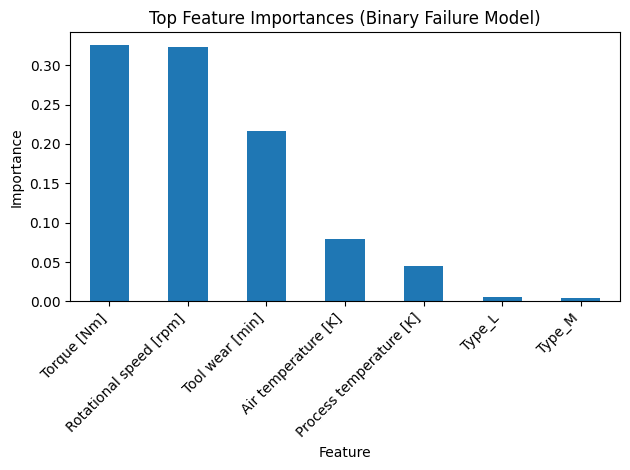

In [71]:
import matplotlib.pyplot as plt

top_n = 10
importances.head(top_n).plot(kind="bar")
plt.title("Top Feature Importances (Binary Failure Model)")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [72]:
train_stats = pd.DataFrame({
    "mean": X_train.mean(),
    "min": X_train.min(),
    "max": X_train.max()
})
train_stats


,mean,min,max
Air temperature [K],300.005450,295.3,304.5
Process temperature [K],310.006062,305.7,313.8
Rotational speed [rpm],1539.356875,1168,2886
Torque [Nm],40.003363,3.8,76.6
Tool wear [min],107.685000,0,253
Type_L,0.603750,False,True
Type_M,0.297625,False,True


In [73]:
def explain_input_vs_training(X_one: pd.DataFrame, stats: pd.DataFrame, top_k: int = 3):
    """
    Returns a simple explanation: which features are unusually high/low compared to training mean.
    """
    row = X_one.iloc[0]
    diffs = (row - stats["mean"]).abs().sort_values(ascending=False)

    explanations = []
    for feat in diffs.head(top_k).index:
        val = row[feat]
        mean = stats.loc[feat, "mean"]
        mn = stats.loc[feat, "min"]
        mx = stats.loc[feat, "max"]

        if val > mean:
            direction = "higher than"
        else:
            direction = "lower than"

        explanations.append(
            f"- **{feat}** is {direction} typical (value={val:.2f}, mean={mean:.2f}, range=[{mn:.2f}, {mx:.2f}])"
        )
    return explanations


In [74]:
# Example: pick a random test sample and explain it
sample = X_test.iloc[[0]]
explain_input_vs_training(sample, train_stats, top_k=5)


['- **Rotational speed [rpm]** is lower than typical (value=1345.00, mean=1539.36, range=[1168.00, 2886.00])',
 '- **Tool wear [min]** is higher than typical (value=153.00, mean=107.69, range=[0.00, 253.00])',
 '- **Torque [Nm]** is higher than typical (value=62.70, mean=40.00, range=[3.80, 76.60])',
 '- **Air temperature [K]** is higher than typical (value=300.50, mean=300.01, range=[295.30, 304.50])',
 '- **Type_L** is higher than typical (value=1.00, mean=0.60, range=[0.00, 1.00])']

In [75]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

artifacts = {
    "rf_binary_model": rf_model,
    "rf_failure_type_model": rf_failure_type,
    "feature_cols": feature_cols,
    "final_threshold": FINAL_THRESHOLD,
    "feature_importances": importances,
    "train_stats": train_stats
}

joblib.dump(artifacts, "../models/vehicle_failure_artifacts.joblib")
print("Artifacts updated with explainability data!")


Artifacts updated with explainability data!


In [76]:
import joblib
import pandas as pd

# Global feature importance
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

# Training stats for local explanation / drift checks
train_stats = pd.DataFrame({
    "mean": X_train.mean(),
    "min": X_train.min(),
    "max": X_train.max()
})

artifacts = {
    "rf_binary_model": rf_model,
    "rf_failure_type_model": rf_failure_type,
    "feature_cols": feature_cols,
    "final_threshold": FINAL_THRESHOLD,
    "feature_importances": importances,
    "train_stats": train_stats
}

joblib.dump(artifacts, "../models/vehicle_failure_artifacts.joblib")
print("Saved artifacts with XAI data!")


Saved artifacts with XAI data!


In [77]:
y_prob_test = rf_model.predict_proba(X_test)[:, 1]


In [78]:
import joblib
import pandas as pd

# XAI objects (if not already created)
feature_importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

train_stats = pd.DataFrame({
    "mean": X_train.mean(),
    "min": X_train.min(),
    "max": X_train.max()
})

artifacts = {
    "rf_binary_model": rf_model,
    "rf_failure_type_model": rf_failure_type,
    "feature_cols": feature_cols,
    "final_threshold": FINAL_THRESHOLD,

    # XAI
    "feature_importances": feature_importances,
    "train_stats": train_stats,

    # Performance (for slider + confusion matrix)
    "y_test": y_test.values,          # numpy array
    "y_prob_test": y_prob_test,       # numpy array
}

joblib.dump(artifacts, "../models/vehicle_failure_artifacts.joblib")
print("Saved artifacts with XAI + performance data!")


Saved artifacts with XAI + performance data!
